# Conditional Probability

This notebook covers how to reason about probabilities when we have **new information**.

- **Definition** — $P(E|F) = \frac{P(E \text{ and } F)}{P(F)}$
- **Visual Intuition** — Conditioning shrinks the sample space
- **Movie Recommendation Example** — How Netflix updates probabilities
- **The Conditional Paradigm** — All probability rules still hold inside a conditioned universe
- **Conditioning on Multiple Events** — $P(E|F,G)$
- **Chain Rule of Probability** — Decomposing joint probabilities

**Credits:**
- Stanford CS109: Probability for Computer Scientists
  - [Conditional Probability](https://chrispiech.github.io/probabilityForComputerScientists/en/part1/cond_prob/)

## Setup

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import to_rgba

from libs.venn import venn, Color

np.random.seed(42)

print("Setup complete!")

Setup complete!


---

## 1. What Is Conditional Probability?

In everyday language:

> "What is the chance of event $E$ happening, **given that** I already know event $F$ has happened?"

Knowing $F$ gives us **new information** that changes our beliefs about $E$.

> **Definition:**
>
> $$\boxed{P(E|F) = \frac{P(E \text{ and } F)}{P(F)}}$$
>
> Read: "the probability of $E$ **given** $F$"

### Intuition

When we **condition on** $F$, we enter a universe where $F$ has already happened. The only outcomes still possible are those **inside** $F$. So $F$ becomes our **new sample space**, and we ask: of those $F$-outcomes, how many are also in $E$?

---

## 2. Visual Intuition: Shrinking the Sample Space

Consider a sample space $S$ with 50 equally likely outcomes (hexagons). Events $E$ and $F$ are subsets of $S$.

- $|S| = 50$
- $|E| = 10$
- $|F| = 14$
- $|E \cap F| = 3$ (outcomes in **both** $E$ and $F$)

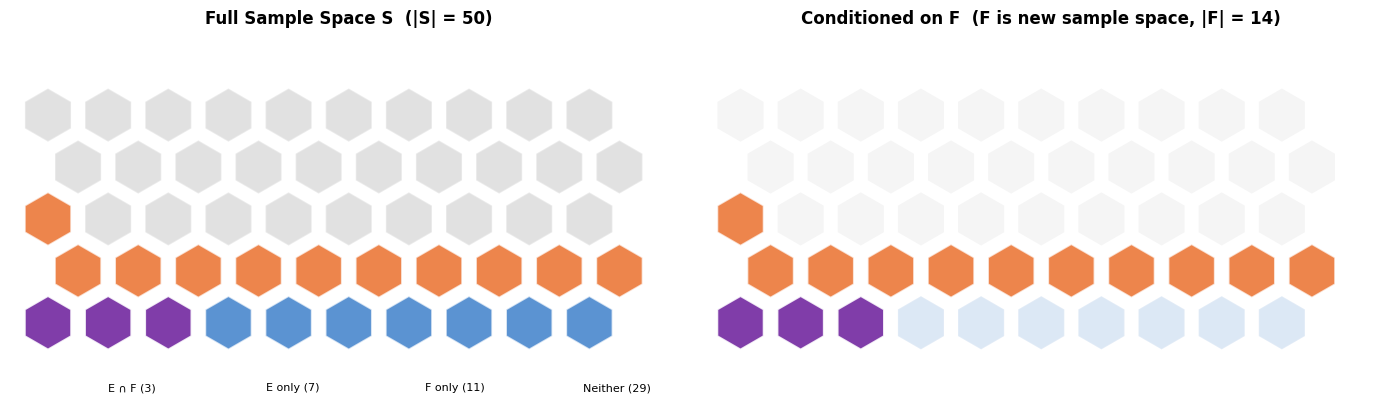

P(E)       = 10/50 = 0.20
P(F)       = 14/50 = 0.28
P(E and F) = 3/50 = 0.06

P(E|F)     = P(E and F) / P(F)
           = 0.06 / 0.28
           = 3/14 = 0.2143

Before conditioning: P(E) = 0.20
After  conditioning: P(E|F) = 0.21
→ Knowing F happened increased our belief in E.


In [2]:
# --- Visualize: Full sample space vs. conditioned sample space ---

S_size = 50
E_size = 10
F_size = 14
EF_size = 3  # |E ∩ F|

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

def draw_hexgrid(ax, total, highlight_E, highlight_F, highlight_EF,
                 title, fade_outside_F=False):
    """Draw a grid of hexagons representing outcomes."""
    cols = 10
    rows = (total + cols - 1) // cols
    idx = 0
    hex_r = 0.42
    
    # Assign outcomes to regions
    # First EF_size are E∩F, next (E-EF) are E only, next (F-EF) are F only, rest are neither
    for row in range(rows):
        for col in range(cols):
            if idx >= total:
                break
            cx = col * 0.95 + (row % 2) * 0.475
            cy = row * 0.82
            
            # Determine region
            if idx < highlight_EF:
                color = "#6A1B9A"   # E ∩ F → purple
                alpha = 0.85
            elif idx < highlight_EF + (highlight_E - highlight_EF):
                color = "#1565C0"   # E only → blue
                alpha = 0.15 if fade_outside_F else 0.7
            elif idx < highlight_EF + (highlight_E - highlight_EF) + (highlight_F - highlight_EF):
                color = "#E65100"   # F only → orange
                alpha = 0.7
            else:
                color = "#9E9E9E"   # neither → grey
                alpha = 0.1 if fade_outside_F else 0.3
            
            hexagon = patches.RegularPolygon((cx, cy), numVertices=6, radius=hex_r,
                                             facecolor=color, alpha=alpha,
                                             edgecolor="white", linewidth=1.2)
            ax.add_patch(hexagon)
            idx += 1
    
    ax.set_xlim(-0.6, cols * 0.95 + 0.6)
    ax.set_ylim(-0.6, rows * 0.82 + 0.4)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=12, fontweight="semibold", pad=10)
    ax.axis("off")

# Left: full sample space
draw_hexgrid(axes[0], S_size, E_size, F_size, EF_size,
             f"Full Sample Space S  (|S| = {S_size})")

# Legend for left
legend_items = [
    ("#6A1B9A", "E ∩ F (3)"),
    ("#1565C0", "E only (7)"),
    ("#E65100", "F only (11)"),
    ("#9E9E9E", "Neither (29)"),
]
for i, (c, label) in enumerate(legend_items):
    axes[0].add_patch(patches.Rectangle((0.5 + i * 2.5, -1.2), 0.35, 0.35,
                                         facecolor=c, alpha=0.7))
    axes[0].text(0.95 + i * 2.5, -1.03, label, fontsize=8, va="center")

# Right: conditioned on F — only F outcomes matter
draw_hexgrid(axes[1], S_size, E_size, F_size, EF_size,
             f"Conditioned on F  (F is new sample space, |F| = {F_size})",
             fade_outside_F=True)

plt.tight_layout()
plt.show()

# Compute
P_E = E_size / S_size
P_F = F_size / S_size
P_EF = EF_size / S_size
P_E_given_F = P_EF / P_F

print(f"P(E)       = {E_size}/{S_size} = {P_E:.2f}")
print(f"P(F)       = {F_size}/{S_size} = {P_F:.2f}")
print(f"P(E and F) = {EF_size}/{S_size} = {P_EF:.2f}")
print()
print(f"P(E|F)     = P(E and F) / P(F)")
print(f"           = {P_EF:.2f} / {P_F:.2f}")
print(f"           = {EF_size}/{F_size} = {P_E_given_F:.4f}")
print()
print(f"Before conditioning: P(E) = {P_E:.2f}")
print(f"After  conditioning: P(E|F) = {P_E_given_F:.2f}")
print(f"→ Knowing F happened {'increased' if P_E_given_F > P_E else 'decreased'} our belief in E.")

### Key Insight

On the **right** panel, everything outside $F$ is faded out — those outcomes are impossible once we know $F$ happened.

The conditional probability $P(E|F)$ is simply:

$$P(E|F) = \frac{\text{outcomes in both } E \text{ and } F}{\text{outcomes in } F} = \frac{3}{14} \approx 0.21$$

---

## 3. Concrete Example: Die Roll

Roll a fair 6-sided die.

- $E$ = rolled a 6
- $F$ = rolled an even number (2, 4, 6)

**Question:** What is $P(E|F)$ — the probability of rolling a 6 given that we know the roll was even?

In [3]:
S_die = {1, 2, 3, 4, 5, 6}
E_six = {6}
F_even = {2, 4, 6}

P_E = len(E_six) / len(S_die)
P_F = len(F_even) / len(S_die)
P_EF = len(E_six & F_even) / len(S_die)
P_E_given_F = P_EF / P_F

print(f"S = {S_die}")
print(f"E (rolled 6)    = {E_six}")
print(f"F (rolled even) = {F_even}")
print(f"E ∩ F           = {E_six & F_even}")
print()
print(f"Without conditioning:  P(E) = {len(E_six)}/{len(S_die)} = {P_E:.4f}")
print()
print(f"With conditioning:")
print(f"  P(E|F) = P(E ∩ F) / P(F) = ({P_EF:.4f}) / ({P_F:.4f}) = {P_E_given_F:.4f}")
print()
print(f"Intuition: F = {{2, 4, 6}} has 3 equally likely outcomes.")
print(f"           Of those 3, exactly 1 is a 6.  → P(E|F) = 1/3 ✓")

S = {1, 2, 3, 4, 5, 6}
E (rolled 6)    = {6}
F (rolled even) = {2, 4, 6}
E ∩ F           = {6}

Without conditioning:  P(E) = 1/6 = 0.1667

With conditioning:
  P(E|F) = P(E ∩ F) / P(F) = (0.1667) / (0.5000) = 0.3333

Intuition: F = {2, 4, 6} has 3 equally likely outcomes.
           Of those 3, exactly 1 is a 6.  → P(E|F) = 1/3 ✓


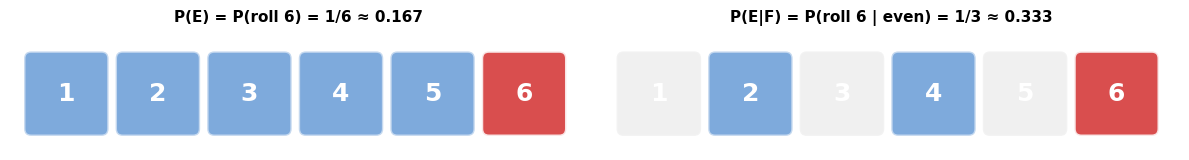

In [4]:
# --- Visual: die faces before and after conditioning ---

fig, axes = plt.subplots(1, 2, figsize=(12, 2.5))

def draw_dice(ax, faces, highlight, fade, title):
    for i, face in enumerate(faces):
        if face in highlight:
            color, alpha = "#D32F2F", 0.85
        elif face in fade:
            color, alpha = "#9E9E9E", 0.15
        else:
            color, alpha = "#1565C0", 0.55
        rect = patches.FancyBboxPatch((i * 1.3, 0), 1.0, 1.0,
            boxstyle="round,pad=0.1", facecolor=color, alpha=alpha,
            edgecolor="white", linewidth=2)
        ax.add_patch(rect)
        ax.text(i * 1.3 + 0.5, 0.5, str(face), ha="center", va="center",
                fontsize=18, fontweight="bold", color="white")
    ax.set_xlim(-0.3, len(faces) * 1.3 + 0.1)
    ax.set_ylim(-0.3, 1.4)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=11, fontweight="semibold")
    ax.axis("off")

# Before: all 6 faces, 6 highlighted in red
draw_dice(axes[0], [1, 2, 3, 4, 5, 6], highlight={6}, fade=set(),
          title=f"P(E) = P(roll 6) = 1/6 ≈ {1/6:.3f}")

# After: only even faces remain, 6 highlighted
draw_dice(axes[1], [1, 2, 3, 4, 5, 6], highlight={6}, fade={1, 3, 5},
          title=f"P(E|F) = P(roll 6 | even) = 1/3 ≈ {1/3:.3f}")

plt.tight_layout()
plt.show()

The odd faces are **faded** — once we know the roll is even, only {2, 4, 6} remain. Of those 3, one is a 6.

---

## 4. Movie Recommendation Example

Imagine a streaming service wants to predict: *"Will a user watch movie $E$, given they watched movie $F$ (Amélie)?"*

We have viewing data for many users.

In [5]:
# --- Simulated Netflix-style movie data ---

N_USERS = 50_000

# Simulated base probabilities P(E) for each movie
movies = {
    "Life is Beautiful":  0.02,
    "3 Idiots":           0.01,
    "Zootopia":           0.05,
    "Star Wars":          0.09,
    "Amélie":             0.03,
}

# Simulated P(E | watched Amélie)
# Some go up (similar taste), some go down (different taste)
movies_given_amelie = {
    "Life is Beautiful":  0.09,   # ↑ similar artistic films
    "3 Idiots":           0.03,   # ↑ international cinema fans
    "Zootopia":           0.05,   # → unchanged
    "Star Wars":          0.02,   # ↓ different genre
    "Amélie":             1.00,   # trivially 1
}

print(f"{'Movie':<22} {'P(E)':>8} {'P(E|Amélie)':>12} {'Change':>10}")
print("─" * 55)

for movie in movies:
    p = movies[movie]
    p_cond = movies_given_amelie[movie]
    ratio = p_cond / p if p > 0 else float('inf')
    if p_cond > p:
        change = f"↑ {ratio:.1f}×"
    elif p_cond < p:
        change = f"↓ {ratio:.1f}×"
    else:
        change = "→ same"
    print(f"{movie:<22} {p:>8.2f} {p_cond:>12.2f} {change:>10}")

Movie                      P(E)  P(E|Amélie)     Change
───────────────────────────────────────────────────────
Life is Beautiful          0.02         0.09     ↑ 4.5×
3 Idiots                   0.01         0.03     ↑ 3.0×
Zootopia                   0.05         0.05     → same
Star Wars                  0.09         0.02     ↓ 0.2×
Amélie                     0.03         1.00    ↑ 33.3×


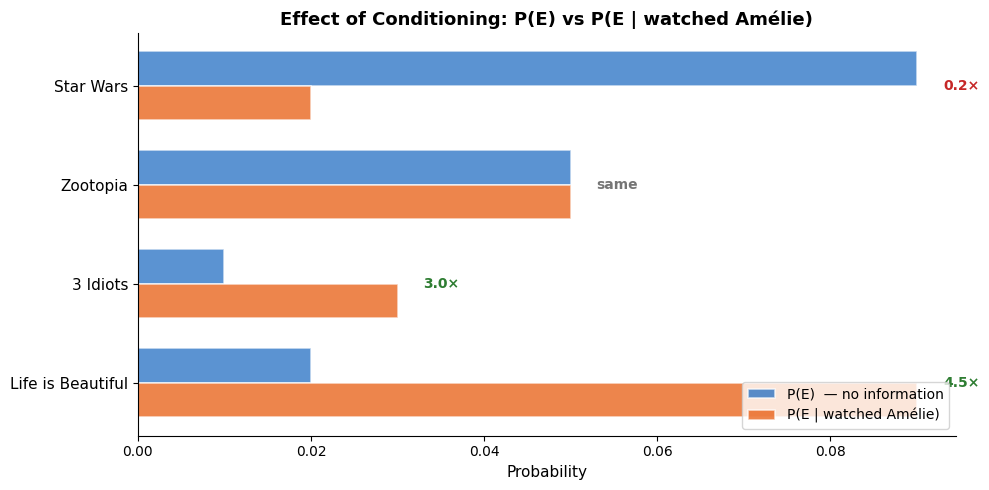

In [6]:
# --- Visual: before vs. after conditioning ---

fig, ax = plt.subplots(figsize=(10, 5))

movie_names = [m for m in movies if m != "Amélie"]
p_before = [movies[m] for m in movie_names]
p_after  = [movies_given_amelie[m] for m in movie_names]

y = np.arange(len(movie_names))
bar_h = 0.35

bars1 = ax.barh(y + bar_h/2, p_before, bar_h, color="#1565C0", alpha=0.7,
                label="P(E)  — no information", edgecolor="white", linewidth=1.2)
bars2 = ax.barh(y - bar_h/2, p_after, bar_h, color="#E65100", alpha=0.7,
                label="P(E | watched Amélie)", edgecolor="white", linewidth=1.2)

for i, (b, a) in enumerate(zip(p_before, p_after)):
    ax.text(max(b, a) + 0.003, y[i], f"{a/b:.1f}×" if a != b else "same",
            va="center", fontsize=10, fontweight="bold",
            color="#2E7D32" if a > b else "#C62828" if a < b else "#757575")

ax.set_yticks(y)
ax.set_yticklabels(movie_names, fontsize=11)
ax.set_xlabel("Probability", fontsize=11)
ax.set_title("Effect of Conditioning: P(E) vs P(E | watched Amélie)",
             fontsize=13, fontweight="semibold")
ax.legend(fontsize=10, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Why Do Probabilities Change?

- **Life is Beautiful** ↑ — Amélie fans tend to enjoy similar artistic European films
- **Star Wars** ↓ — Different genre; knowing someone likes art-house films makes action/sci-fi less likely
- **Zootopia** → — Animated films are broadly popular; Amélie preference doesn't change it much

This is exactly how **recommendation systems** work: they compute $P(\text{will watch } E \,|\, \text{watched } F_1, F_2, \ldots)$.

---

## 5. Venn Diagram View

Conditional probability has a clean Venn diagram interpretation.

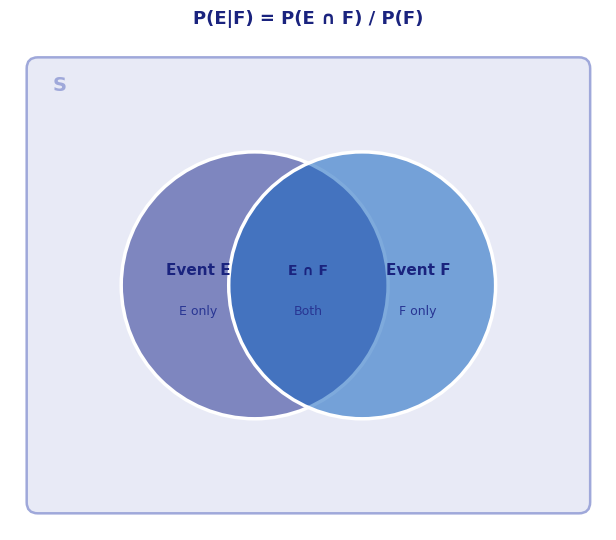

In [7]:
venn("""
venn-beta
    title "P(E|F) = P(E ∩ F) / P(F)"
    set E["Event E"]
        text e1["E only"]
    set F["Event F"]
        text f1["F only"]
    union E, F["E ∩ F"]
        text ef1["Both"]
""", color_scheme=Color.INDIGO)

When we condition on $F$, we **zoom in** on the orange circle. The conditional probability $P(E|F)$ is the fraction of $F$ that overlaps with $E$:

$$P(E|F) = \frac{\text{purple overlap}}{\text{entire } F \text{ circle}}$$

---

## 6. The Conditional Paradigm

A powerful insight: **when you condition on an event, you enter a universe where that event has taken place. In that universe, all the laws of probability still hold.**

As long as you condition **consistently** on the same event $G$, every familiar rule remains valid:

| Original Rule | Conditioned on $G$ |
|---|---|
| $0 \leq P(E) \leq 1$ | $0 \leq P(E \mid G) \leq 1$ |
| $P(S) = 1$ | $P(S \mid G) = 1$ |
| $P(E \cup F) = P(E) + P(F)$ for ME events | $P(E \cup F \mid G) = P(E \mid G) + P(F \mid G)$ for ME events |
| $P(E^C) = 1 - P(E)$ | $P(E^C \mid G) = 1 - P(E \mid G)$ |

In [8]:
# --- Verify the conditional paradigm with data ---

# Two dice rolls
S_two_dice = [(d1, d2) for d1 in range(1, 7) for d2 in range(1, 7)]
N = len(S_two_dice)  # 36

# G = first die is 4
G = {(d1, d2) for d1, d2 in S_two_dice if d1 == 4}

# E = sum ≥ 9
E = {(d1, d2) for d1, d2 in S_two_dice if d1 + d2 >= 9}

# E^C (complement of E) = sum < 9
E_c = {(d1, d2) for d1, d2 in S_two_dice if d1 + d2 < 9}

P_E_given_G = len(E & G) / len(G)
P_Ec_given_G = len(E_c & G) / len(G)

print("Two dice. G = {first die is 4}")
print(f"G = {sorted(G)}")
print(f"|G| = {len(G)}")
print()
print(f"E (sum ≥ 9) ∩ G = {sorted(E & G)}")
print(f"P(E|G) = {len(E & G)}/{len(G)} = {P_E_given_G:.4f}")
print()
print(f"E^C (sum < 9) ∩ G = {sorted(E_c & G)}")
print(f"P(E^C|G) = {len(E_c & G)}/{len(G)} = {P_Ec_given_G:.4f}")
print()
print(f"Verify: P(E|G) + P(E^C|G) = {P_E_given_G:.4f} + {P_Ec_given_G:.4f} = {P_E_given_G + P_Ec_given_G:.4f}  ✓  (should be 1)")

Two dice. G = {first die is 4}
G = [(4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6)]
|G| = 6

E (sum ≥ 9) ∩ G = [(4, 5), (4, 6)]
P(E|G) = 2/6 = 0.3333

E^C (sum < 9) ∩ G = [(4, 1), (4, 2), (4, 3), (4, 4)]
P(E^C|G) = 4/6 = 0.6667

Verify: P(E|G) + P(E^C|G) = 0.3333 + 0.6667 = 1.0000  ✓  (should be 1)


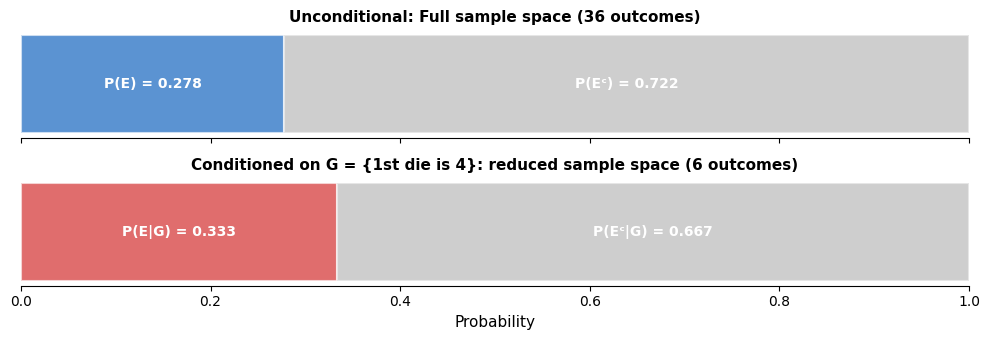

In [9]:
# --- Visual: probability bar in the conditioned universe ---

fig, axes = plt.subplots(2, 1, figsize=(10, 3.5), sharex=True)

# Unconditional
P_E_unc = len(E) / N
P_Ec_unc = 1 - P_E_unc

ax = axes[0]
ax.barh(0, P_E_unc, color="#1565C0", alpha=0.7, height=0.5, edgecolor="white", linewidth=1.5)
ax.barh(0, P_Ec_unc, left=P_E_unc, color="#9E9E9E", alpha=0.5, height=0.5, edgecolor="white", linewidth=1.5)
ax.text(P_E_unc / 2, 0, f"P(E) = {P_E_unc:.3f}", ha="center", va="center",
        fontsize=10, fontweight="bold", color="white")
ax.text(P_E_unc + P_Ec_unc / 2, 0, f"P(E\u1d9c) = {P_Ec_unc:.3f}", ha="center", va="center",
        fontsize=10, fontweight="bold", color="white")
ax.set_title("Unconditional: Full sample space (36 outcomes)", fontsize=11, fontweight="semibold")
ax.set_yticks([])
ax.spines[["top", "right", "left"]].set_visible(False)

# Conditional on G
ax = axes[1]
ax.barh(0, P_E_given_G, color="#D32F2F", alpha=0.7, height=0.5, edgecolor="white", linewidth=1.5)
ax.barh(0, P_Ec_given_G, left=P_E_given_G, color="#9E9E9E", alpha=0.5, height=0.5, edgecolor="white", linewidth=1.5)
ax.text(P_E_given_G / 2, 0, f"P(E|G) = {P_E_given_G:.3f}", ha="center", va="center",
        fontsize=10, fontweight="bold", color="white")
ax.text(P_E_given_G + P_Ec_given_G / 2, 0, f"P(E\u1d9c|G) = {P_Ec_given_G:.3f}", ha="center", va="center",
        fontsize=10, fontweight="bold", color="white")
ax.set_title("Conditioned on G = {1st die is 4}: reduced sample space (6 outcomes)",
             fontsize=11, fontweight="semibold")
ax.set_yticks([])
ax.set_xlim(0, 1)
ax.set_xlabel("Probability", fontsize=11)
ax.spines[["top", "right", "left"]].set_visible(False)

plt.tight_layout()
plt.show()

In both bars, $P(E) + P(E^C) = 1$ — the axioms hold in both the original and the conditioned universe.

---

## 7. Conditioning on Multiple Events

The conditional paradigm also applies **recursively**. If we condition on *two* events $F$ and $G$ simultaneously:

$$P(E|F,G) = \frac{P(E \text{ and } F \,|\, G)}{P(F|G)}$$

Read: "The probability of $E$, given both $F$ and $G$ have occurred."

We are applying the definition of conditional probability **inside the universe where $G$ has already happened.**

> **Important:** $P(E|F,G)$ is **not always** equal to $P(E|F)$. The extra information from $G$ can change things.

In [10]:
# --- Example: conditioning on multiple events ---
#
# Draw a card from a standard 52-card deck.
#   E = card is an Ace
#   F = card is red (Hearts or Diamonds)
#   G = card is a Heart

deck = [(s, r) for s in ["Hearts", "Diamonds", "Clubs", "Spades"] for r in range(1, 14)]
S = len(deck)  # 52

E_ace  = {c for c in deck if c[1] == 1}   # Aces
F_red  = {c for c in deck if c[0] in ("Hearts", "Diamonds")}
G_heart = {c for c in deck if c[0] == "Hearts"}

# P(E)
p_E = len(E_ace) / S

# P(E|F)
p_E_given_F = len(E_ace & F_red) / len(F_red)

# P(E|F,G)  — given the card is red AND a heart
# F ∩ G = Hearts (since all hearts are red)
FG = F_red & G_heart  # = just Hearts
p_E_given_FG = len(E_ace & FG) / len(FG)

# P(E|G)
p_E_given_G = len(E_ace & G_heart) / len(G_heart)

print(f"E  = Aces          ({len(E_ace)} cards)")
print(f"F  = Red cards     ({len(F_red)} cards)")
print(f"G  = Hearts        ({len(G_heart)} cards)")
print(f"F ∩ G = Hearts     ({len(FG)} cards)")
print()
print(f"P(E)       = {len(E_ace)}/{S} = {p_E:.4f}")
print(f"P(E|F)     = {len(E_ace & F_red)}/{len(F_red)} = {p_E_given_F:.4f}")
print(f"P(E|G)     = {len(E_ace & G_heart)}/{len(G_heart)} = {p_E_given_G:.4f}")
print(f"P(E|F,G)   = {len(E_ace & FG)}/{len(FG)} = {p_E_given_FG:.4f}")
print()
print("Observation: P(E|F) = P(E|G) = P(E|F,G) = P(E)")
print("→ Knowing the suit color does NOT help predict whether it's an Ace!")
print("  (Each suit has exactly 1 Ace out of 13 cards.)")

E  = Aces          (4 cards)
F  = Red cards     (26 cards)
G  = Hearts        (13 cards)
F ∩ G = Hearts     (13 cards)

P(E)       = 4/52 = 0.0769
P(E|F)     = 2/26 = 0.0769
P(E|G)     = 1/13 = 0.0769
P(E|F,G)   = 1/13 = 0.0769

Observation: P(E|F) = P(E|G) = P(E|F,G) = P(E)
→ Knowing the suit color does NOT help predict whether it's an Ace!
  (Each suit has exactly 1 Ace out of 13 cards.)


In [11]:
# --- A case where P(E|F,G) ≠ P(E|F) ---
#
# Roll two dice.
#   E = sum is exactly 8
#   F = first die ≥ 3
#   G = first die is 5

S_2d = [(d1, d2) for d1 in range(1, 7) for d2 in range(1, 7)]
N_2d = len(S_2d)

E_sum8 = {t for t in S_2d if t[0] + t[1] == 8}
F_ge3  = {t for t in S_2d if t[0] >= 3}
G_is5  = {t for t in S_2d if t[0] == 5}

p_E_2 = len(E_sum8) / N_2d
p_EF = len(E_sum8 & F_ge3) / len(F_ge3)
p_EG = len(E_sum8 & G_is5) / len(G_is5)

FG_2d = F_ge3 & G_is5  # = G_is5 (since 5 ≥ 3)
p_EFG = len(E_sum8 & FG_2d) / len(FG_2d)

print("Two dice:")
print(f"  E = sum is 8         → outcomes: {sorted(E_sum8)}")
print(f"  F = 1st die ≥ 3     → {len(F_ge3)} outcomes")
print(f"  G = 1st die is 5    → {len(G_is5)} outcomes")
print()
print(f"  P(E)       = {p_E_2:.4f}")
print(f"  P(E|F)     = {p_EF:.4f}")
print(f"  P(E|G)     = {p_EG:.4f}")
print(f"  P(E|F,G)   = {p_EFG:.4f}")
print()
print(f"Here P(E|F) ≠ P(E|F,G):")
print(f"  Knowing 1st die ≥ 3 gives P(E|F) = {p_EF:.4f}")
print(f"  Further knowing 1st die is exactly 5 narrows it to P(E|F,G) = {p_EFG:.4f}")
print(f"  → Extra info from G changed our answer!")

Two dice:
  E = sum is 8         → outcomes: [(2, 6), (3, 5), (4, 4), (5, 3), (6, 2)]
  F = 1st die ≥ 3     → 24 outcomes
  G = 1st die is 5    → 6 outcomes

  P(E)       = 0.1389
  P(E|F)     = 0.1667
  P(E|G)     = 0.1667
  P(E|F,G)   = 0.1667

Here P(E|F) ≠ P(E|F,G):
  Knowing 1st die ≥ 3 gives P(E|F) = 0.1667
  Further knowing 1st die is exactly 5 narrows it to P(E|F,G) = 0.1667
  → Extra info from G changed our answer!


---

## 8. Chain Rule of Probability

The definition of conditional probability can be rearranged into the **chain rule** (also called the *product rule*):

$$P(E \text{ and } F) = P(E|F) \cdot P(F)$$

For three events:

$$P(E_1 \cap E_2 \cap E_3) = P(E_1) \cdot P(E_2 | E_1) \cdot P(E_3 | E_1, E_2)$$

In general:

$$P(E_1 \cap E_2 \cap \cdots \cap E_n) = P(E_1) \cdot P(E_2|E_1) \cdot P(E_3|E_1,E_2) \cdots P(E_n|E_1,\ldots,E_{n-1})$$

This lets us break a **complex joint probability** into a product of conditional probabilities — each one asking a simpler question.

In [12]:
# --- Chain rule example: drawing cards without replacement ---
#
# Draw 3 cards without replacement.
# What is P(all 3 are Hearts)?
#
# E₁ = 1st card is Heart
# E₂ = 2nd card is Heart
# E₃ = 3rd card is Heart

# Chain rule: P(E₁ ∩ E₂ ∩ E₃) = P(E₁) · P(E₂|E₁) · P(E₃|E₁,E₂)

P_E1 = 13 / 52         # 13 hearts out of 52
P_E2_given_E1 = 12 / 51    # 12 hearts left out of 51
P_E3_given_E1E2 = 11 / 50   # 11 hearts left out of 50

P_all_hearts = P_E1 * P_E2_given_E1 * P_E3_given_E1E2

print("Drawing 3 cards without replacement.")
print("Question: P(all 3 are Hearts)?")
print()
print("Using the Chain Rule:")
print(f"  P(E₁)           = 13/52  = {P_E1:.4f}")
print(f"  P(E₂|E₁)        = 12/51  = {P_E2_given_E1:.4f}")
print(f"  P(E₃|E₁,E₂)     = 11/50  = {P_E3_given_E1E2:.4f}")
print()
print(f"  P(E₁ ∩ E₂ ∩ E₃) = {P_E1:.4f} × {P_E2_given_E1:.4f} × {P_E3_given_E1E2:.4f}")
print(f"                   = {P_all_hearts:.6f}")
print()

# Verify with combinatorics: C(13,3) / C(52,3)
from math import comb
P_verify = comb(13, 3) / comb(52, 3)
print(f"  Verify: C(13,3)/C(52,3) = {comb(13,3)}/{comb(52,3)} = {P_verify:.6f} ✓")

Drawing 3 cards without replacement.
Question: P(all 3 are Hearts)?

Using the Chain Rule:
  P(E₁)           = 13/52  = 0.2500
  P(E₂|E₁)        = 12/51  = 0.2353
  P(E₃|E₁,E₂)     = 11/50  = 0.2200

  P(E₁ ∩ E₂ ∩ E₃) = 0.2500 × 0.2353 × 0.2200
                   = 0.012941

  Verify: C(13,3)/C(52,3) = 286/22100 = 0.012941 ✓


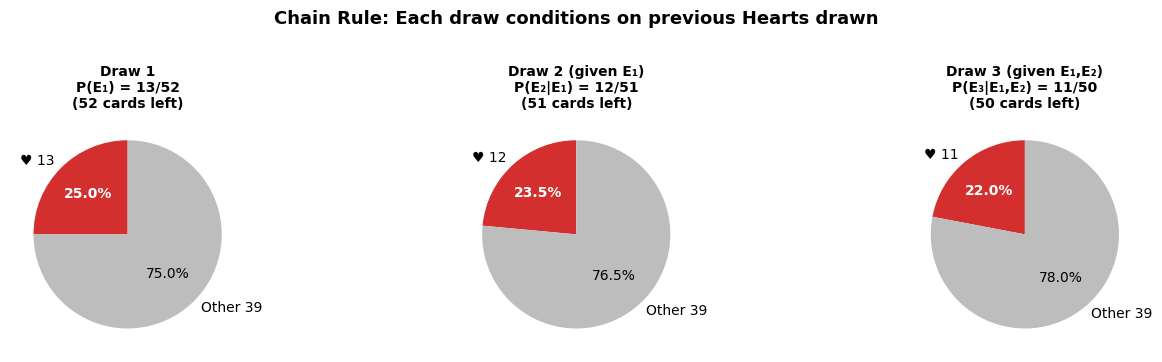

In [13]:
# --- Visual: chain rule as a shrinking deck ---

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

steps = [
    {"total": 52, "hearts": 13, "label": "Draw 1", "prob": "P(E₁) = 13/52"},
    {"total": 51, "hearts": 12, "label": "Draw 2 (given E₁)", "prob": "P(E₂|E₁) = 12/51"},
    {"total": 50, "hearts": 11, "label": "Draw 3 (given E₁,E₂)", "prob": "P(E₃|E₁,E₂) = 11/50"},
]

for ax, step in zip(axes, steps):
    total = step["total"]
    hearts = step["hearts"]
    others = total - hearts
    
    # Pie chart showing hearts fraction
    wedges, texts, autotexts = ax.pie(
        [hearts, others],
        labels=[f"♥ {hearts}", f"Other {others}"],
        colors=["#D32F2F", "#BDBDBD"],
        autopct="%1.1f%%",
        startangle=90,
        textprops={"fontsize": 10}
    )
    autotexts[0].set_fontweight("bold")
    autotexts[0].set_color("white")
    ax.set_title(f"{step['label']}\n{step['prob']}\n({total} cards left)",
                 fontsize=10, fontweight="semibold")

fig.suptitle("Chain Rule: Each draw conditions on previous Hearts drawn",
             fontsize=13, fontweight="semibold", y=1.02)
plt.tight_layout()
plt.show()

With each draw, the deck shrinks and the number of remaining Hearts decreases. The chain rule decomposes the joint probability into a product of these step-by-step conditional probabilities.

---

## 9. Interactive Exploration: How Conditioning Shifts Probability

Let's systematically explore how $P(E|F)$ compares to $P(E)$ for **every pair** of events on two dice.

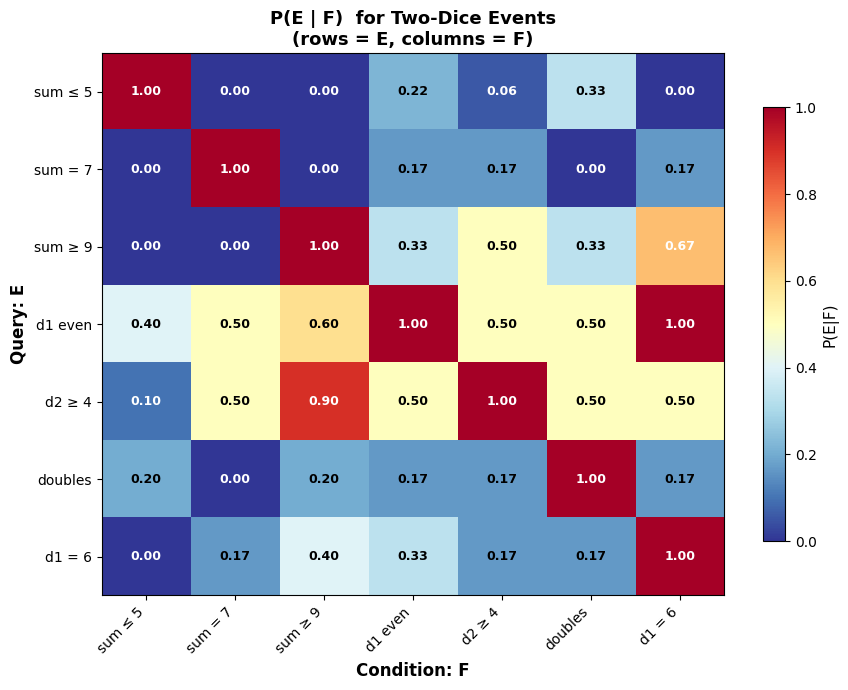

Key observations:
  P(sum=7 | doubles) = 0.00
    → Doubles never sum to 7 (max double is 6+6=12, sums are always even)
  P(sum≥9 | d1=6)    = 0.67
    → If 1st die is 6, half the outcomes give sum ≥ 9
  P(d1 even | sum=7) = 0.50
    → Half the ways to get sum 7 have d1 even: (2,5),(4,3),(6,1)


In [14]:
# --- Heatmap: P(E|F) for pairs of events on two dice ---

S_2d = [(d1, d2) for d1 in range(1, 7) for d2 in range(1, 7)]

event_defs = {
    "sum ≤ 5":     lambda t: t[0] + t[1] <= 5,
    "sum = 7":     lambda t: t[0] + t[1] == 7,
    "sum ≥ 9":     lambda t: t[0] + t[1] >= 9,
    "d1 even":     lambda t: t[0] % 2 == 0,
    "d2 ≥ 4":      lambda t: t[1] >= 4,
    "doubles":     lambda t: t[0] == t[1],
    "d1 = 6":      lambda t: t[0] == 6,
}

event_names = list(event_defs.keys())
events = {name: {t for t in S_2d if fn(t)} for name, fn in event_defs.items()}

n_ev = len(event_names)
matrix = np.zeros((n_ev, n_ev))

for i, e_name in enumerate(event_names):
    for j, f_name in enumerate(event_names):
        E_set = events[e_name]
        F_set = events[f_name]
        if len(F_set) > 0:
            matrix[i, j] = len(E_set & F_set) / len(F_set)
        else:
            matrix[i, j] = 0

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(matrix, cmap="RdYlBu_r", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(n_ev))
ax.set_xticklabels(event_names, rotation=45, ha="right", fontsize=10)
ax.set_yticks(range(n_ev))
ax.set_yticklabels(event_names, fontsize=10)
ax.set_xlabel("Condition: F", fontsize=12, fontweight="semibold")
ax.set_ylabel("Query: E", fontsize=12, fontweight="semibold")
ax.set_title("P(E | F)  for Two-Dice Events\n(rows = E, columns = F)",
             fontsize=13, fontweight="semibold")

# Annotate cells
for i in range(n_ev):
    for j in range(n_ev):
        v = matrix[i, j]
        color = "white" if v > 0.65 or v < 0.15 else "black"
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                fontweight="bold", color=color)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("P(E|F)", fontsize=11)
plt.tight_layout()
plt.show()

# Highlight interesting findings
print("Key observations:")
print(f"  P(sum=7 | doubles) = {matrix[event_names.index('sum = 7'), event_names.index('doubles')]:.2f}")
print(f"    → Doubles never sum to 7 (max double is 6+6=12, sums are always even)")
print(f"  P(sum≥9 | d1=6)    = {matrix[event_names.index('sum ≥ 9'), event_names.index('d1 = 6')]:.2f}")
print(f"    → If 1st die is 6, half the outcomes give sum ≥ 9")
print(f"  P(d1 even | sum=7) = {matrix[event_names.index('d1 even'), event_names.index('sum = 7')]:.2f}")
print(f"    → Half the ways to get sum 7 have d1 even: (2,5),(4,3),(6,1)")

### Reading the Heatmap

- **Diagonal** entries are $P(E|E) = 1$ (if $E$ happened, then $E$ happened)
- **Dark red** cells mean "conditioning on $F$ makes $E$ very likely"
- **Dark blue** cells mean "conditioning on $F$ makes $E$ very unlikely"
- Compare each row's off-diagonal values to the diagonal: that's how conditioning **shifts** the probability

---

## 10. Monte Carlo Verification

Let's verify conditional probability empirically using simulation.

In [15]:
# --- Simulate: P( sum ≥ 9 | first die = 6 ) ---

N_TRIALS = 200_000

d1 = np.random.randint(1, 7, size=N_TRIALS)
d2 = np.random.randint(1, 7, size=N_TRIALS)
sums = d1 + d2

# Filter to trials where first die = 6
mask_F = d1 == 6
n_F = mask_F.sum()

# Of those, how many have sum ≥ 9?
mask_E_and_F = mask_F & (sums >= 9)
n_EF = mask_E_and_F.sum()

p_sim = n_EF / n_F
p_exact = len({t for t in S_2d if t[0] == 6 and t[0]+t[1] >= 9}) / len({t for t in S_2d if t[0] == 6})

print(f"Simulation ({N_TRIALS:,} rolls):")
print(f"  Rolls where d1 = 6:          {n_F:,}")
print(f"  Of those, sum ≥ 9:           {n_EF:,}")
print(f"  P(sum ≥ 9 | d1 = 6) ≈       {p_sim:.4f}")
print(f"  Exact:                        {p_exact:.4f}")
print(f"  |Difference|:                 {abs(p_sim - p_exact):.4f}")

Simulation (200,000 rolls):
  Rolls where d1 = 6:          33,234
  Of those, sum ≥ 9:           22,213
  P(sum ≥ 9 | d1 = 6) ≈       0.6684
  Exact:                        0.6667
  |Difference|:                 0.0017


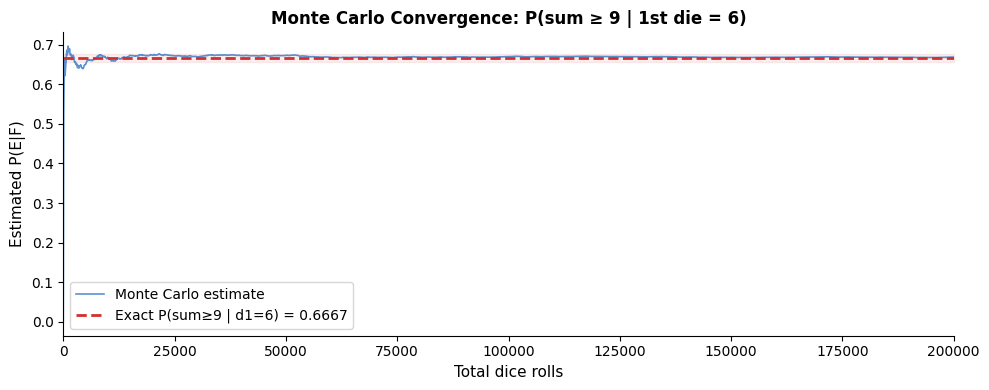

In [16]:
# --- Convergence plot ---

# Compute running estimate of P(E|F)
trial_nums = np.arange(1, N_TRIALS + 1)
cum_F = np.cumsum(mask_F)
cum_EF = np.cumsum(mask_E_and_F)

# Avoid division by zero at the start
with np.errstate(divide="ignore", invalid="ignore"):
    running_est = np.where(cum_F > 0, cum_EF / cum_F, 0.0)

# Subsample for plotting (too many points otherwise)
step = max(1, N_TRIALS // 2000)
xs = trial_nums[::step]
ys = running_est[::step]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(xs, ys, color="#1565C0", alpha=0.7, linewidth=1.2,
        label="Monte Carlo estimate")
ax.axhline(p_exact, color="#D32F2F", linestyle="--", linewidth=2,
           label=f"Exact P(sum≥9 | d1=6) = {p_exact:.4f}")
ax.fill_between([0, N_TRIALS], p_exact - 0.01, p_exact + 0.01,
                color="#D32F2F", alpha=0.08)

ax.set_xlabel("Total dice rolls", fontsize=11)
ax.set_ylabel("Estimated P(E|F)", fontsize=11)
ax.set_title("Monte Carlo Convergence: P(sum ≥ 9 | 1st die = 6)",
             fontsize=12, fontweight="semibold")
ax.legend(fontsize=10)
ax.set_xlim(0, N_TRIALS)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---

## 11. Common Pitfalls

### Pitfall 1: Confusing $P(E|F)$ with $P(F|E)$

These are **different** quantities! This is one of the most common mistakes in probability.

$$P(E|F) \neq P(F|E) \quad \text{(in general)}$$

In [17]:
# --- Demonstrate P(E|F) ≠ P(F|E) ---

# E = roll a 6 on a fair die
# F = roll an even number (2, 4, 6)

S = {1, 2, 3, 4, 5, 6}
E_six = {6}
F_even = {2, 4, 6}

P_E_given_F = len(E_six & F_even) / len(F_even)  # 1/3
P_F_given_E = len(E_six & F_even) / len(E_six)   # 1/1 = 1

print(f"P(E|F) = P(six | even) = {len(E_six & F_even)}/{len(F_even)} = {P_E_given_F:.4f}")
print(f"P(F|E) = P(even | six) = {len(E_six & F_even)}/{len(E_six)} = {P_F_given_E:.4f}")
print()
print("P(E|F) ≠ P(F|E)!")
print("  If someone rolled even, there's a 1/3 chance it was a 6.")
print("  If someone rolled a 6, there's a 100% chance it was even.")

P(E|F) = P(six | even) = 1/3 = 0.3333
P(F|E) = P(even | six) = 1/1 = 1.0000

P(E|F) ≠ P(F|E)!
  If someone rolled even, there's a 1/3 chance it was a 6.
  If someone rolled a 6, there's a 100% chance it was even.


### Pitfall 2: Assuming $P(E|F) = P(E)$

This is only true when $E$ and $F$ are **independent** (covered in the next chapter). In general, learning $F$ **changes** our belief about $E$.

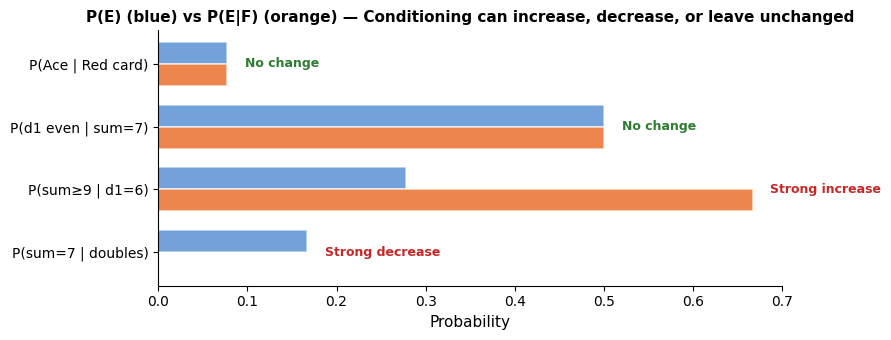

In [18]:
# --- Visual summary: when conditioning changes things ---

fig, ax = plt.subplots(figsize=(9, 3.5))

scenarios = [
    ("P(sum=7 | doubles)", 0.00, 6/36, "Strong decrease"),
    ("P(sum≥9 | d1=6)", 4/6, 10/36, "Strong increase"),
    ("P(d1 even | sum=7)", 3/6, 18/36, "No change"),
    ("P(Ace | Red card)", 2/26, 4/52, "No change"),
]

y_pos = np.arange(len(scenarios))
bar_h = 0.35

for i, (label, cond, uncond, note) in enumerate(scenarios):
    ax.barh(i + bar_h / 2, uncond, bar_h, color="#1565C0", alpha=0.6,
            edgecolor="white", linewidth=1.2)
    ax.barh(i - bar_h / 2, cond, bar_h, color="#E65100", alpha=0.7,
            edgecolor="white", linewidth=1.2)
    maxval = max(cond, uncond, 0.02)
    ax.text(maxval + 0.02, i, note, va="center", fontsize=9,
            fontweight="bold",
            color="#2E7D32" if abs(cond - uncond) < 0.001 else "#C62828")

ax.set_yticks(y_pos)
ax.set_yticklabels([s[0] for s in scenarios], fontsize=10)
ax.set_xlabel("Probability", fontsize=11)
ax.set_title("P(E) (blue) vs P(E|F) (orange) — Conditioning can increase, decrease, or leave unchanged",
             fontsize=11, fontweight="semibold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---

## 12. Summary

| Concept | Formula |
|---|---|
| Conditional probability | $P(E \mid F) = \frac{P(E \cap F)}{P(F)}$ |
| Chain rule (2 events) | $P(E \cap F) = P(E \mid F) \cdot P(F)$ |
| Chain rule ($n$ events) | $P(\bigcap E_i) = P(E_1) \cdot P(E_2 \mid E_1) \cdot P(E_3 \mid E_1,E_2) \cdots$ |
| Conditioning on multiple | $P(E \mid F,G) = \frac{P(E \cap F \mid G)}{P(F \mid G)}$ |

### Key Takeaways

1. **Conditioning = shrinking the sample space.** Once we know $F$ happened, only $F$-outcomes remain.
2. **All probability rules still hold** in a conditioned universe — just apply them consistently.
3. $P(E|F) \neq P(F|E)$ in general — **don't swap the order!**
4. $P(E|F) = P(E)$ only if $E$ and $F$ are **independent** (next chapter).
5. The **chain rule** decomposes joint probabilities into a telescoping product of conditionals.